##Probleam Statement:
The objective is to build a machine learning solution to predict employee attrition (Yes/No) and identify key factors driving it.

1.	Data Understanding Report
2. Feature Engineering Documentation
3.	Model Development and Evaluation Report
4.	Insights and Recommendations Report


In [ ]:
## Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Load Dataset

In [ ]:
df=pd.read_csv("/content/HR_Employee-Attrition.csv")
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [ ]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,2,Male,82,4,2,Laboratory Technician,3,Married,4404,10228,2,Y,No,12,3,1,80,0,6,3,4,4,3,1,2


#EDA

# Basic Data Check

In [ ]:
df.shape

(1470, 35)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [ ]:
df.drop('EmployeeCount', axis='columns', inplace=True)
df.drop('Over18', axis='columns', inplace=True )

#Handline Null Value

In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeNumber,0
EnvironmentSatisfaction,0


##Checking Duplicate Values

In [ ]:
df.duplicated().sum()

np.int64(0)

#Split Data into Categorical and Numerical Col

In [ ]:
from pandas.core.arrays import categorical
categorical_col=df.select_dtypes(include='object').columns
numerical_col=df.select_dtypes(exclude='object')

In [ ]:
categorical_col

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')

In [ ]:
numerical_col.tail()

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,884,23,2,2061,3,41,4,2,4,2571,12290,4,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,613,6,1,2062,4,42,2,3,1,9991,21457,4,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,155,4,3,2064,2,87,4,2,2,6142,5174,1,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,1023,2,3,2065,4,63,2,2,2,5390,13243,2,14,3,4,80,0,17,3,2,9,6,0,8
1469,34,628,8,3,2068,2,82,4,2,3,4404,10228,2,12,3,1,80,0,6,3,4,4,3,1,2


In [ ]:
for i in categorical_col:
  print(df[i].value_counts())
  print("--"*20)

Attrition
No     1233
Yes     237
Name: count, dtype: int64
----------------------------------------
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
----------------------------------------
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
----------------------------------------
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
----------------------------------------
Gender
Male      882
Female    588
Name: count, dtype: int64
----------------------------------------
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Rese

#Outliers

In [ ]:
for col in numerical_col:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)

  IQR=Q3-Q1


  LB=Q1-1.5*IQR
  UB=Q3+1.5*IQR

  df=df[(df[col]>=LB) & (df[col]<=UB)]

In [ ]:
df.shape

(699, 33)

##Univariate/Bivariate analysis of the features

#Key Observations
* More employees staying than leaving.
* Most employees fall in the 25–40 age group.
* Income distribution is right-skewed (most employees earn lower to mid-range salaries).
* Fewer employees are in higher salary brackets, which may influence retention.
* Majority of employees have less than 10 years of experience at the company.
*	Most employees have spent 2–4 years in the same role.
*	Limited role changes may indicate stagnation, potentially leading to attrition.
*	Many employees have worked in 1–3 companies, indicating moderate job switching behavior.
*	Most employees receive moderate salary hikes (11–15%).
*	Lack of higher increments could be a factor in employee dissatisfaction.


<Axes: xlabel='MonthlyIncome', ylabel='Count'>

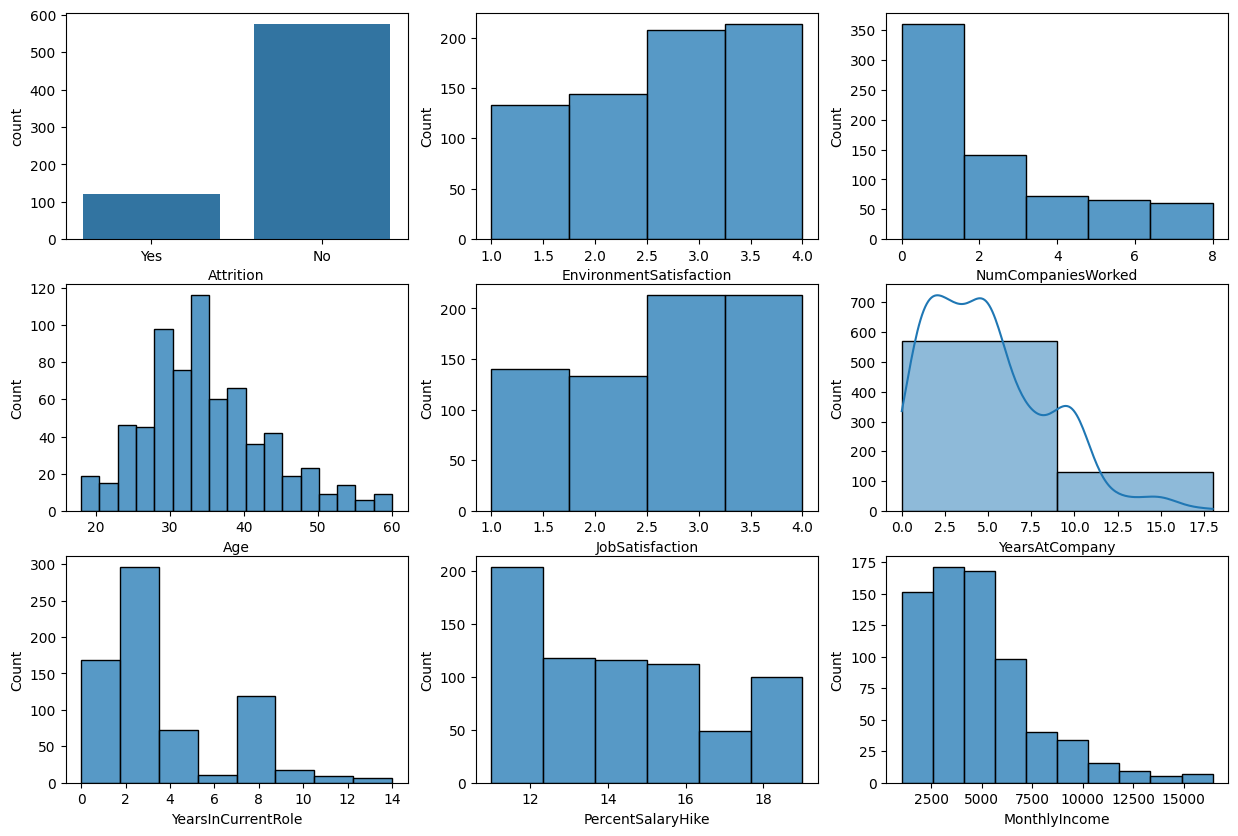

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15,10))

sns.countplot(x='Attrition', data=df, ax=axes[0,0])
sns.histplot(df['EnvironmentSatisfaction'], bins=4, ax=axes[0,1])
sns.histplot(df['NumCompaniesWorked'], bins=5, ax=axes[0,2])
sns.histplot(x='Age', data=df, ax=axes[1,0])
sns.histplot(df['JobSatisfaction'], bins=4, ax=axes[1,1])
sns.histplot(df['YearsAtCompany'], kde=True,bins=2, ax=axes[1,2])
sns.histplot(df['YearsInCurrentRole'], bins=8, ax=axes[2,0])
sns.histplot(df['PercentSalaryHike'], bins=6, ax=axes[2,1])
sns.histplot(df['MonthlyIncome'], bins=10, ax=axes[2,2])

#Observations

* Employees who are single tend to leave more frequently
* Sales roles show higher attrition rates
Employees who travel frequently are more likely to leave
* Higher salary and job level reduce attrition risk
* Longer tenure with company and manager improves retention


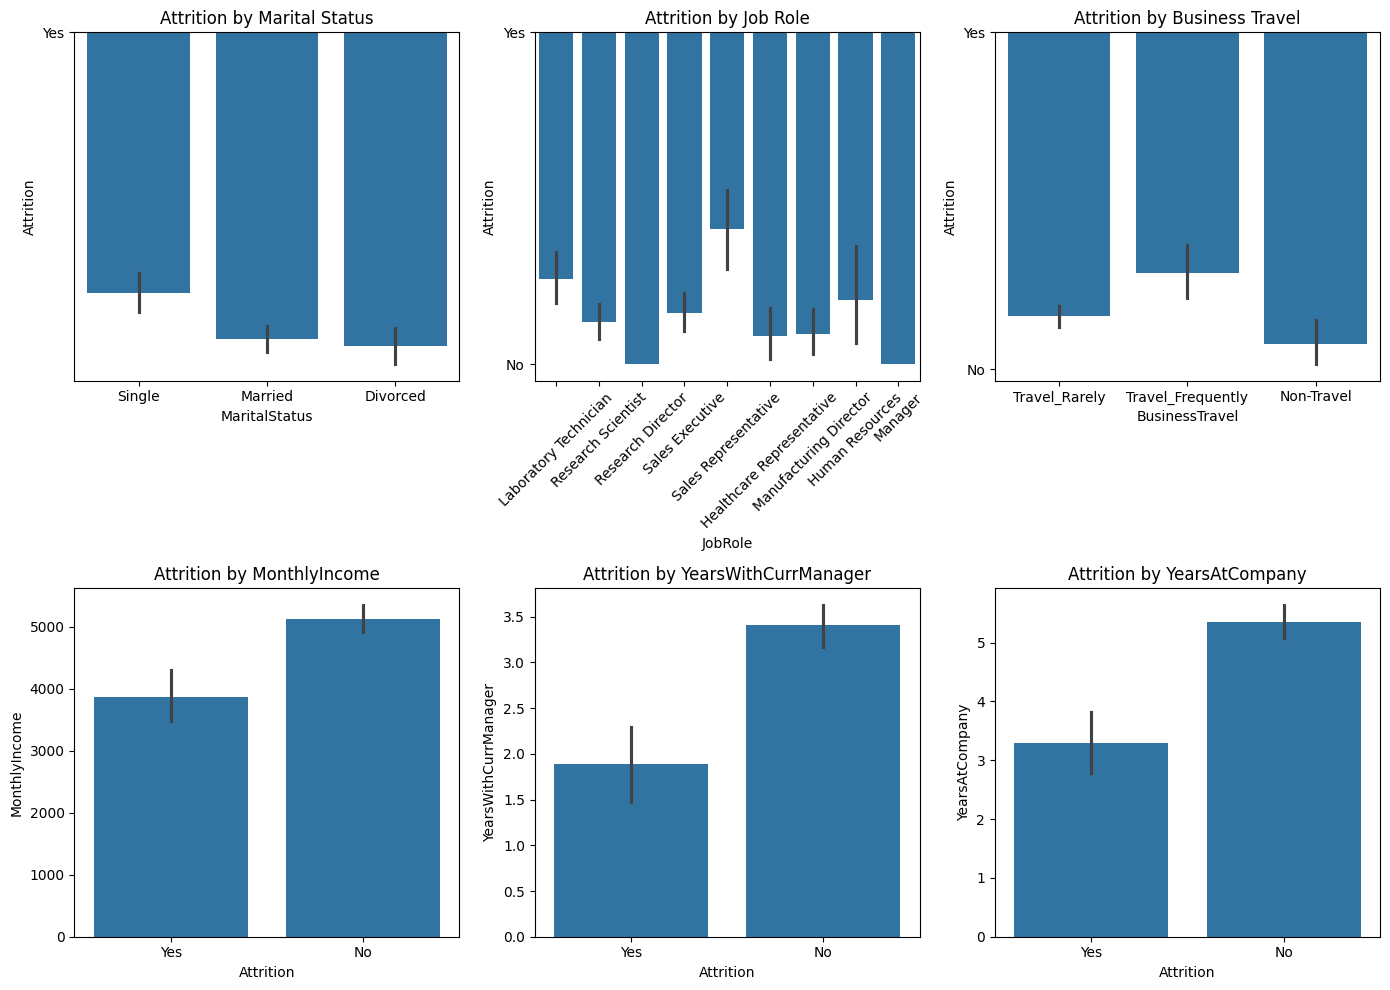

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14,10))


sns.barplot(x='MaritalStatus', y='Attrition', data=df, ax=axes[0,0])
axes[0,0].set_title("Attrition by Marital Status")

sns.barplot(x='JobRole', y='Attrition', data=df, ax=axes[0,1])
axes[0,1].set_title("Attrition by Job Role")
axes[0,1].tick_params(axis='x', rotation=45)

sns.barplot(x='BusinessTravel', y='Attrition', data=df, ax=axes[0,2])
axes[0,2].set_title("Attrition by Business Travel")

sns.barplot(x='Attrition', y='MonthlyIncome', data=df, ax=axes[1,0])
axes[1,0].set_title("Attrition by MonthlyIncome")


sns.barplot(x='Attrition', y='YearsWithCurrManager', data=df, ax=axes[1,1])
axes[1,1].set_title("Attrition by YearsWithCurrManager")

sns.barplot(x='Attrition', y='YearsAtCompany', data=df, ax=axes[1,2])
axes[1,2].set_title("Attrition by YearsAtCompany")

plt.tight_layout()
plt.show()

## Converting Categorical data into Numerical Data

In [ ]:
categorical_col

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder as lableEncoder
le_d={}

In [ ]:
for col in categorical_col:
  le=lableEncoder()
  df[col]=le.fit_transform(df[col])
  le_d[col]=le

In [ ]:
le_d

{'Attrition': LabelEncoder(),
 'BusinessTravel': LabelEncoder(),
 'Department': LabelEncoder(),
 'EducationField': LabelEncoder(),
 'Gender': LabelEncoder(),
 'JobRole': LabelEncoder(),
 'MaritalStatus': LabelEncoder(),
 'OverTime': LabelEncoder()}

In [ ]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1463,31,0,0,325,1,5,3,3,2057,2,1,74,3,2,4,1,2,9936,3787,0,0,19,3,2,80,0,10,2,3,9,4,1,7
1464,26,0,2,1167,2,5,3,4,2060,4,0,30,2,1,8,3,2,2966,21378,0,0,18,3,4,80,0,5,2,3,4,2,0,0
1465,36,0,1,884,1,23,2,3,2061,3,1,41,4,2,2,4,1,2571,12290,4,0,17,3,3,80,1,17,3,3,5,2,0,3
1468,49,0,1,1023,2,2,3,3,2065,4,1,63,2,2,7,2,1,5390,13243,2,0,14,3,4,80,0,17,3,2,9,6,0,8
1469,34,0,2,628,1,8,3,3,2068,2,1,82,4,2,2,3,1,4404,10228,2,0,12,3,1,80,0,6,3,4,4,3,1,2


#Bivariate analysis of the features
* Employees doing overtime are most likely to leave

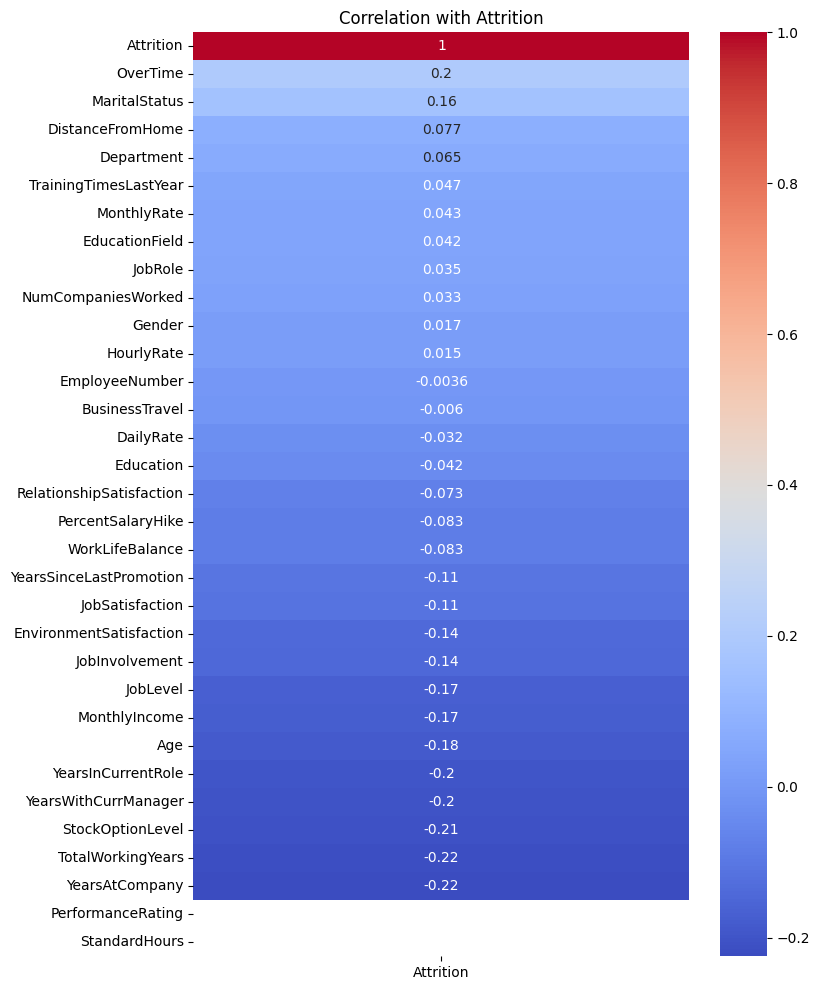

In [ ]:
plt.figure(figsize=(8,12))
corr = df.corr()[['Attrition']].sort_values(by='Attrition', ascending=False)
#print(corr)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation with Attrition")
plt.show()

#Model Building

In [ ]:
#Divide the dataset into X(input), y(output)

X=df.drop('Attrition',axis=1)
y=df['Attrition']


In [ ]:
#Divide the dataset into Train, test using train_test_split.

X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.7)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((489, 32), (210, 32), (489,), (210,))

#Initializing model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
lr=LogisticRegression()
nb=GaussianNB()
rf=RandomForestClassifier()
dt=DecisionTreeClassifier()


#Model Training

In [ ]:
lr.fit(X_train, y_train)
nb.fit(X_train, y_train)
rf.fit(X_train, y_train)
dt.fit(X_train, y_train)

DecisionTreeClassifier()

#Model evaluation

In [ ]:
lr_pred = lr.predict(X_test)
nb_pred = nb.predict(X_test)
rf_pred = rf.predict(X_test)
dt_pred = dt.predict(X_test)

In [ ]:
## Confusion matrix print for all

print("Confusion matrix")
print(metrics.confusion_matrix(y_test, rf_pred))

Confusion matrix
[[175   0]
 [ 29   6]]


#Compare y_pred and y_test and calcuate the evalaution parameters

In [ ]:
# Accuracy
lr_acc = metrics.accuracy_score(y_test, lr_pred)
nb_acc = metrics.accuracy_score(y_test, nb_pred)
rf_acc = metrics.accuracy_score(y_test, rf_pred)
dt_acc = metrics.accuracy_score(y_test, dt_pred)

# Precision
lr_prec = metrics.precision_score(y_test, lr_pred)
nb_prec = metrics.precision_score(y_test, nb_pred)
rf_prec = metrics.precision_score(y_test, rf_pred)
dt_prec = metrics.precision_score(y_test, dt_pred)

# Recall
lr_rec = metrics.recall_score(y_test, lr_pred)
nb_rec = metrics.recall_score(y_test, nb_pred)
rf_rec = metrics.recall_score(y_test, rf_pred)
dt_rec = metrics.recall_score(y_test, dt_pred)

In [ ]:
# Accuracy
print("Accuracy for Logistic Regression : ", lr_acc)
print("Accuracy for Naive Bayes: ", nb_acc)
print("Accuracy for Random Forest: ", rf_acc)
print("Accuracy for Decision Tree: ", dt_acc)
print("--"*20)
# Precision
print("Precision for Logistic Regression : ", lr_prec)
print("Precision for Naive Bayes: ", nb_prec)
print("Precision for Random Forest: ", rf_prec)
print("Precision for Decision Tree: ", dt_prec)
print("--"*20)
# Recall
print("Recall for Logistic Regression : ", lr_rec)
print("Recall for Naive Bayes: ", nb_rec)
print("Recall for Random Forest: ", rf_rec)
print("Recall for Decision Tree: ", dt_rec)

Accuracy for Logistic Regression :  0.8238095238095238
Accuracy for Naive Bayes:  0.7142857142857143
Accuracy for Random Forest:  0.861904761904762
Accuracy for Decision Tree:  0.7666666666666667
----------------------------------------
Precision for Logistic Regression :  0.3333333333333333
Precision for Naive Bayes:  0.3076923076923077
Precision for Random Forest:  1.0
Precision for Decision Tree:  0.3409090909090909
----------------------------------------
Recall for Logistic Regression :  0.05714285714285714
Recall for Naive Bayes:  0.5714285714285714
Recall for Random Forest:  0.17142857142857143
Recall for Decision Tree:  0.42857142857142855


In [ ]:
best_model = rf

#Prediction

In [ ]:
new_data= pd.DataFrame({
    "Age": 34,
    "BusinessTravel": "Travel_Rarely",
    "DailyRate": 1102,
    "Department": "Research & Development",
    "DistanceFromHome": 8,
    "Education": 3,
    "EducationField": "Life Sciences",
    "EmployeeNumber": 1456,
    "EnvironmentSatisfaction": 4,
    "Gender": "Male",
    "HourlyRate": 58,
    "JobInvolvement": 3,
    "JobLevel": 2,
    "JobRole": "Laboratory Technician",
    "JobSatisfaction": 0,
    "MaritalStatus": "Married",
    "MonthlyIncome": 5200,
    "MonthlyRate": 19479,
    "NumCompaniesWorked": 2,
    "OverTime": "No",
    "PercentSalaryHike": 14,
    "PerformanceRating": 3,
    "RelationshipSatisfaction": 3,
    "StandardHours": 80,
    "StockOptionLevel": 1,
    "TotalWorkingYears": 10,
    "TrainingTimesLastYear": 3,
    "WorkLifeBalance": 3,
    "YearsAtCompany": 0,
    "YearsInCurrentRole": 4,
    "YearsSinceLastPromotion": 1,
    "YearsWithCurrManager": 4
}, index=[0])

In [ ]:
new_data

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,34,Travel_Rarely,1102,Research & Development,8,3,Life Sciences,1456,4,Male,58,3,2,Laboratory Technician,0,Married,5200,19479,2,No,14,3,3,80,1,10,3,3,0,4,1,4


In [ ]:

categorical_col

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'OverTime'],
      dtype='object')

In [ ]:
new_data['BusinessTravel'] = le_d['BusinessTravel'].transform(new_data['BusinessTravel'])
new_data['Department'] = le_d['Department'].transform(new_data['Department'])
new_data['EducationField'] = le_d['EducationField'].transform(new_data['EducationField'])
new_data['Gender'] = le_d['Gender'].transform(new_data['Gender'])
new_data['JobRole'] = le_d['JobRole'].transform(new_data['JobRole'])
new_data['MaritalStatus'] = le_d['MaritalStatus'].transform(new_data['MaritalStatus'])
new_data['OverTime'] = le_d['OverTime'].transform(new_data['OverTime'])

In [ ]:
prediction = best_model.predict(new_data)

In [ ]:
prediction

array([0])

In [ ]:
print(le_d['Attrition'].inverse_transform(prediction))

['No']
